In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cleaned_Country_data.csv")

# Set style
sns.set_style("whitegrid")

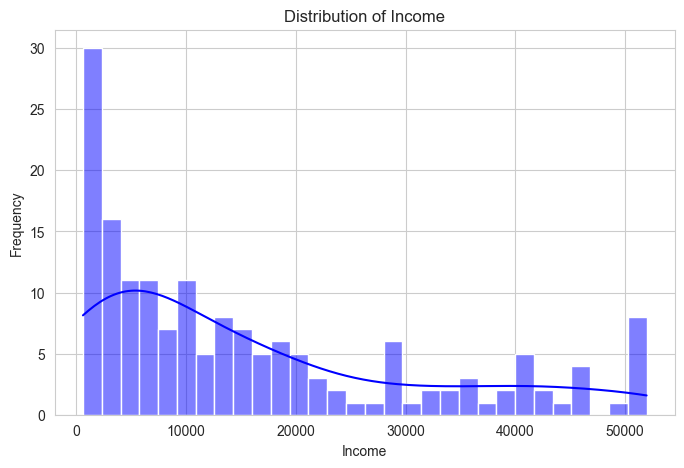

In [3]:
#Univariate Analysis
# Distribution of income

plt.figure(figsize=(8,5))
sns.histplot(df['income'], kde=True, bins=30, color='blue')
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

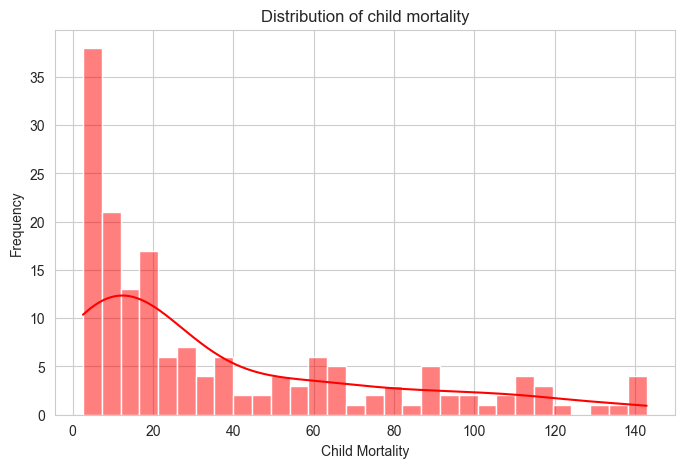

In [5]:
# Distribution of child mortality

plt.figure(figsize=(8,5))
sns.histplot(df['child_mort'], kde=True, bins=30, color='red')
plt.title("Distribution of child mortality")
plt.xlabel("Child Mortality")
plt.ylabel("Frequency")
plt.show()

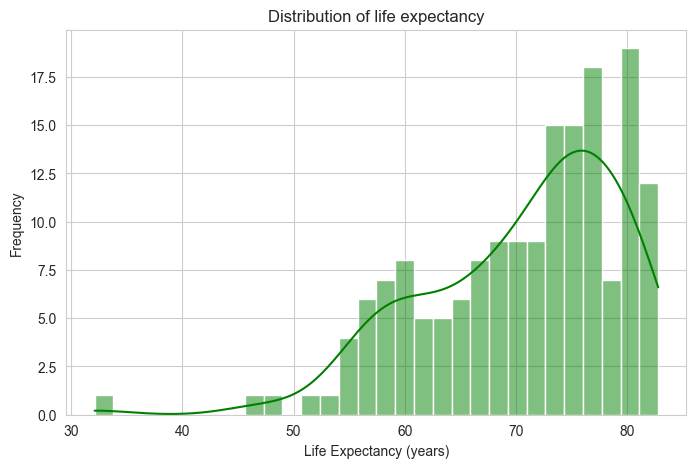

In [6]:
# Distribution of life expectancy

plt.figure(figsize=(8,5))
sns.histplot(df['life_expec'], kde=True, bins=30, color='green')
plt.title("Distribution of life expectancy")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Frequency")
plt.show()

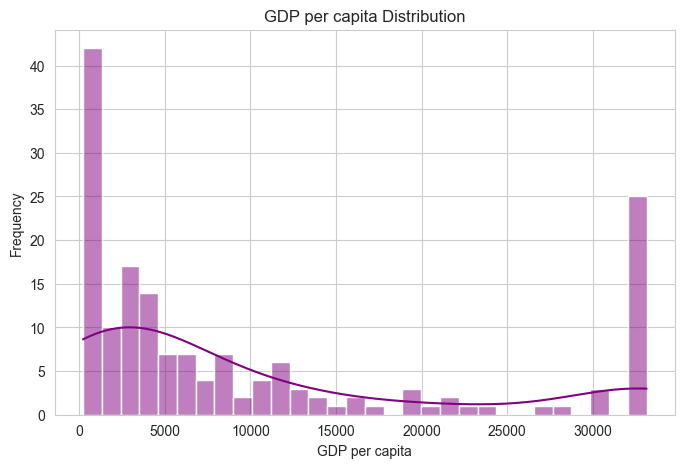

In [7]:
# GDP per capita spread

plt.figure(figsize=(8,5))
sns.histplot(df['gdpp'], kde=True, bins=30, color='purple')
plt.title("GDP per capita Distribution")
plt.xlabel("GDP per capita")
plt.ylabel("Frequency")
plt.show()

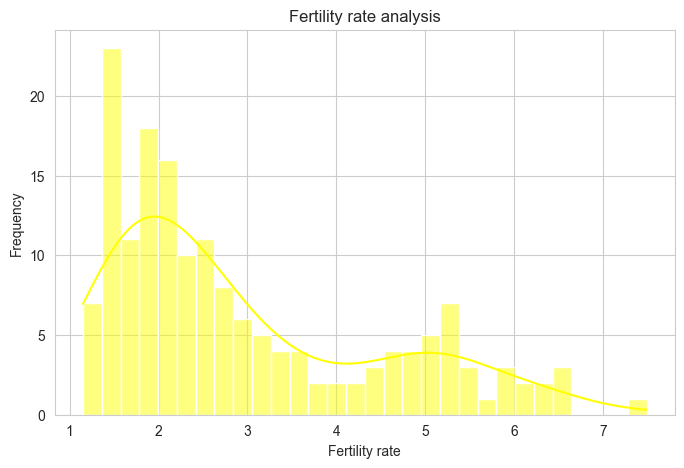

In [8]:
# Fertility rate analysis

plt.figure(figsize=(8,5))
sns.histplot(df['total_fer'], kde=True, bins=30, color='yellow')
plt.title("Fertility rate analysis")
plt.xlabel("Fertility rate")
plt.ylabel("Frequency")
plt.show()

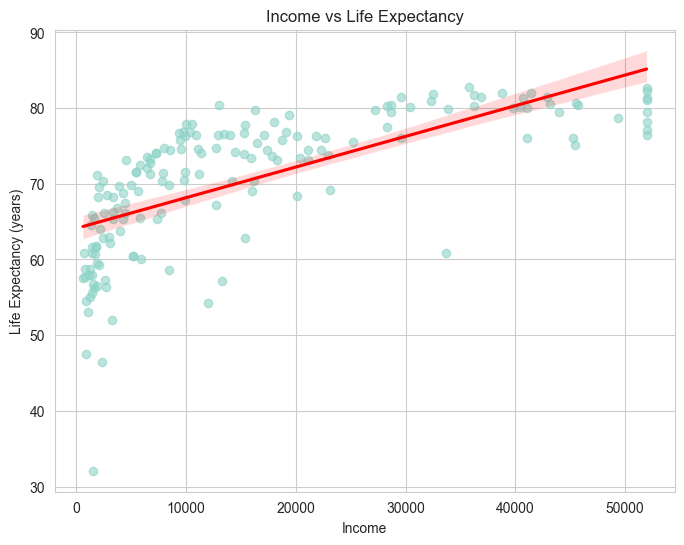

In [9]:
# Bivariate / Multivariate Analysis
# Income vs Life Expectancy


plt.figure(figsize=(8,6))
sns.regplot(x="income", y="life_expec", data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Income vs Life Expectancy")
plt.xlabel("Income")
plt.ylabel("Life Expectancy (years)")
plt.show()

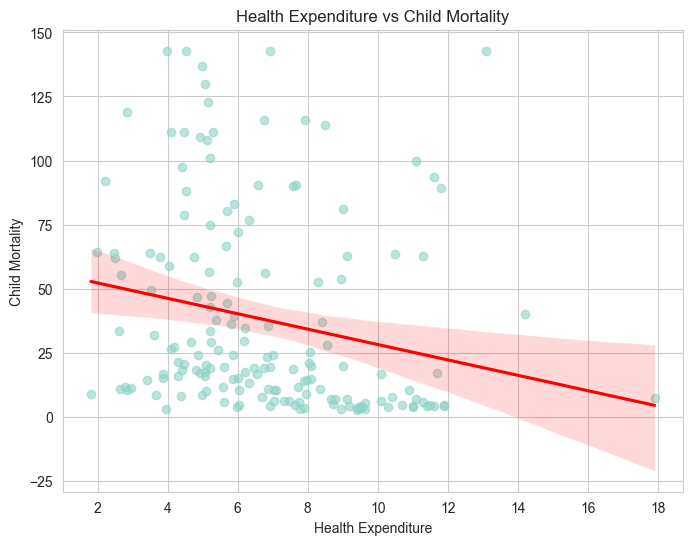

In [10]:
# Health Expenditure vs Child Mortality


plt.figure(figsize=(8,6))
sns.regplot(x="health", y="child_mort", data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Health Expenditure vs Child Mortality")
plt.xlabel("Health Expenditure")
plt.ylabel("Child Mortality")
plt.show()

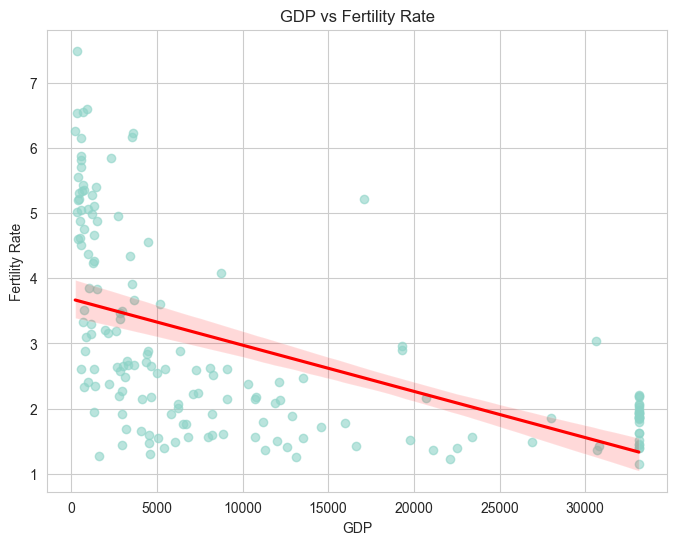

In [11]:
# GDP vs Fertility Rate


plt.figure(figsize=(8,6))
sns.regplot(x="gdpp", y="total_fer", data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("GDP vs Fertility Rate")
plt.xlabel("GDP")
plt.ylabel("Fertility Rate")
plt.show()

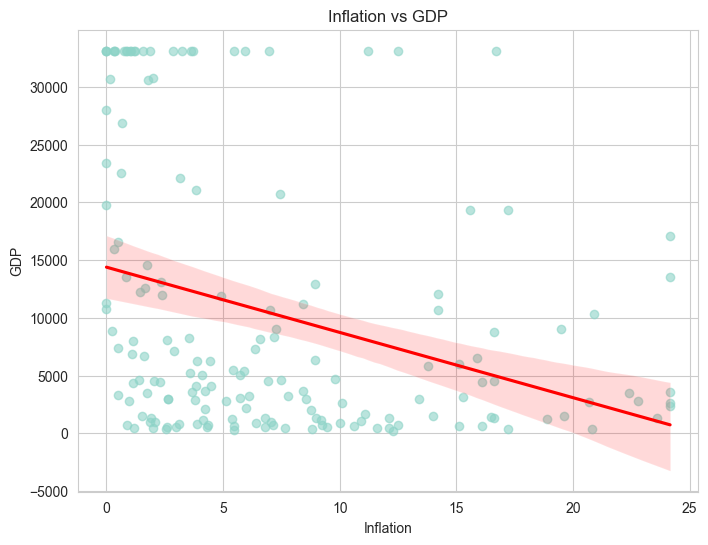

In [12]:
# Inflation vs GDP


plt.figure(figsize=(8,6))
sns.regplot(x="inflation", y="gdpp", data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Inflation vs GDP")
plt.xlabel("Inflation")
plt.ylabel("GDP")
plt.show()

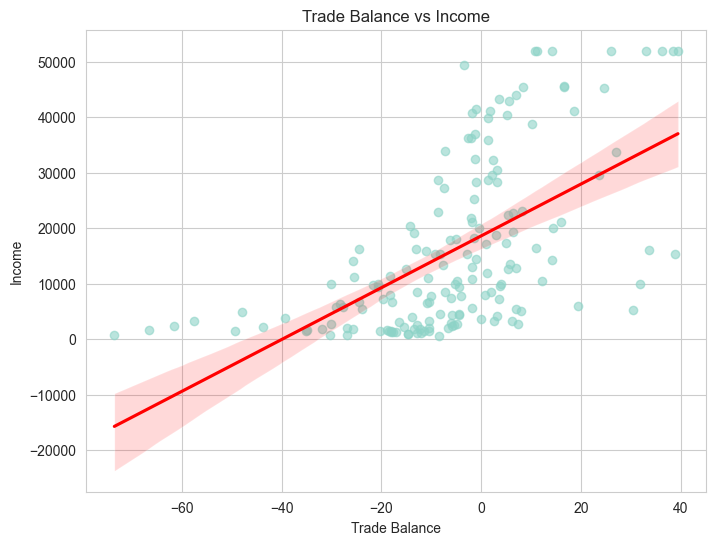

In [13]:
# Trade Balance vs Income
# Scatter plot with regression line

plt.figure(figsize=(8,6))
sns.regplot(x="Trade_Balance", y="income", data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Trade Balance vs Income")
plt.xlabel("Trade Balance")
plt.ylabel("Income")
plt.show()

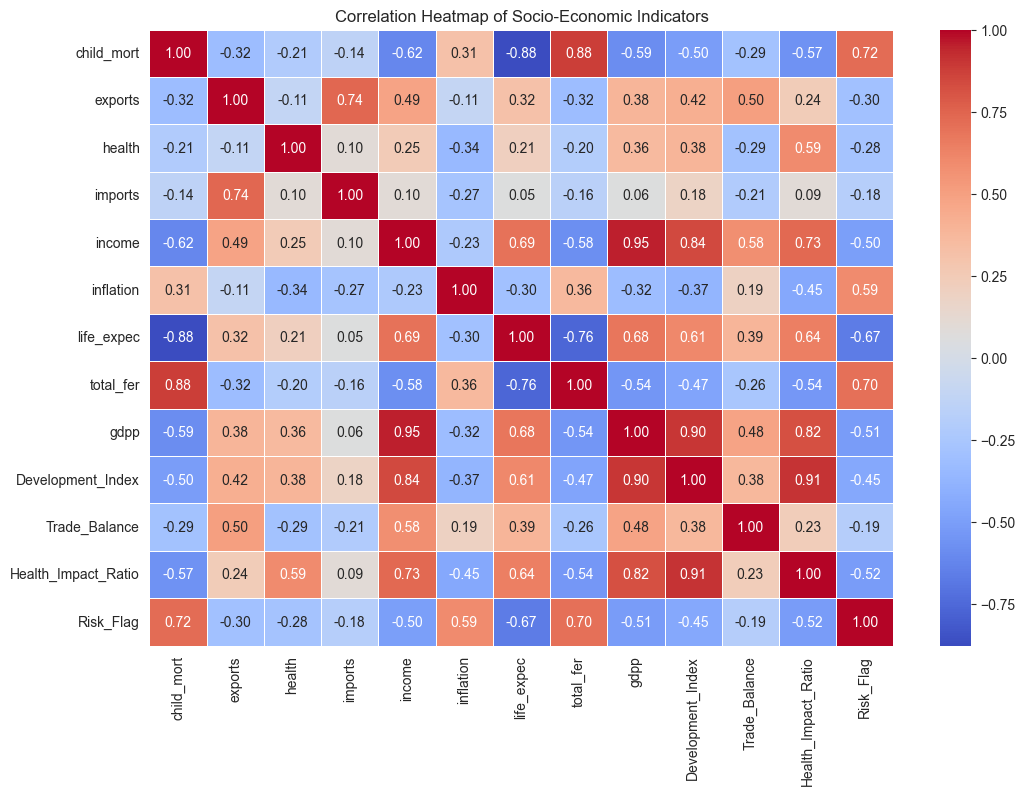

In [14]:
# Correlation Analysis
# Correlation heatmap

corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Socio-Economic Indicators")
plt.show()

# Identify strongest predictors of life expectancy and mortality
* Life Expectancy Predictors
    > Child Mortality: Strong negative correlation (higher mortality → lower life expectancy)
* Child Mortality Predictors
    > Life Expectancy: Strong negative correlation (higher life expectancy → lower child mortality)



In [15]:
# Group by Segment and calculate KPIs
segment_summary = df.groupby('Segment').agg({
    'income': 'mean',
    'gdpp': 'mean',
    'child_mort': 'mean',
    'life_expec': 'mean',
    'inflation': 'mean',
    'total_fer': 'mean',
    'health': 'mean',
    'Trade_Balance': 'mean',
    'Development_Index': 'mean',
    'Health_Impact_Ratio': 'mean'
}).reset_index()

print(segment_summary)


               Segment        income          gdpp  child_mort  life_expec  \
0     Developed Nation  42265.576923  32522.692308    4.596154   80.792308   
1     Emerging Economy  16386.406250   9849.843750   17.826563   74.025000   
2      Health Critical   3980.000000   1140.000000   78.900000   63.800000   
3  High Inflation Risk  15664.821429   7839.428571   60.107143   67.185714   
4    High Risk Country   1696.653846    697.115385  107.430769   56.730769   
5         Low GDP Trap   2718.823529   1019.235294   50.517647   65.741176   
6                Other  10402.500000   5596.842105   24.357895   70.926316   

   inflation  total_fer    health  Trade_Balance  Development_Index  \
0   2.296423   1.748462  9.305769       7.723077       18273.952985   
1   6.440484   2.107969  6.737812      -2.012500        3090.205352   
2   9.200000   3.150000  4.470000     -13.900000          65.700887   
3  20.045714   4.107143  4.792857       6.255714        1386.770759   
4   7.987885   5.380